In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import platform
import matplotlib.pyplot as plt
import math


# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("data/Courses.csv")

In [4]:
df['step'] = np.select(
    [
        df['certified'] ==1,
        df['explored'] == 1,
        df['viewed'] == 1,
        df['registered'] == 1,
    ],
    [
        3,
        2,
        1,
        0
    ]
)

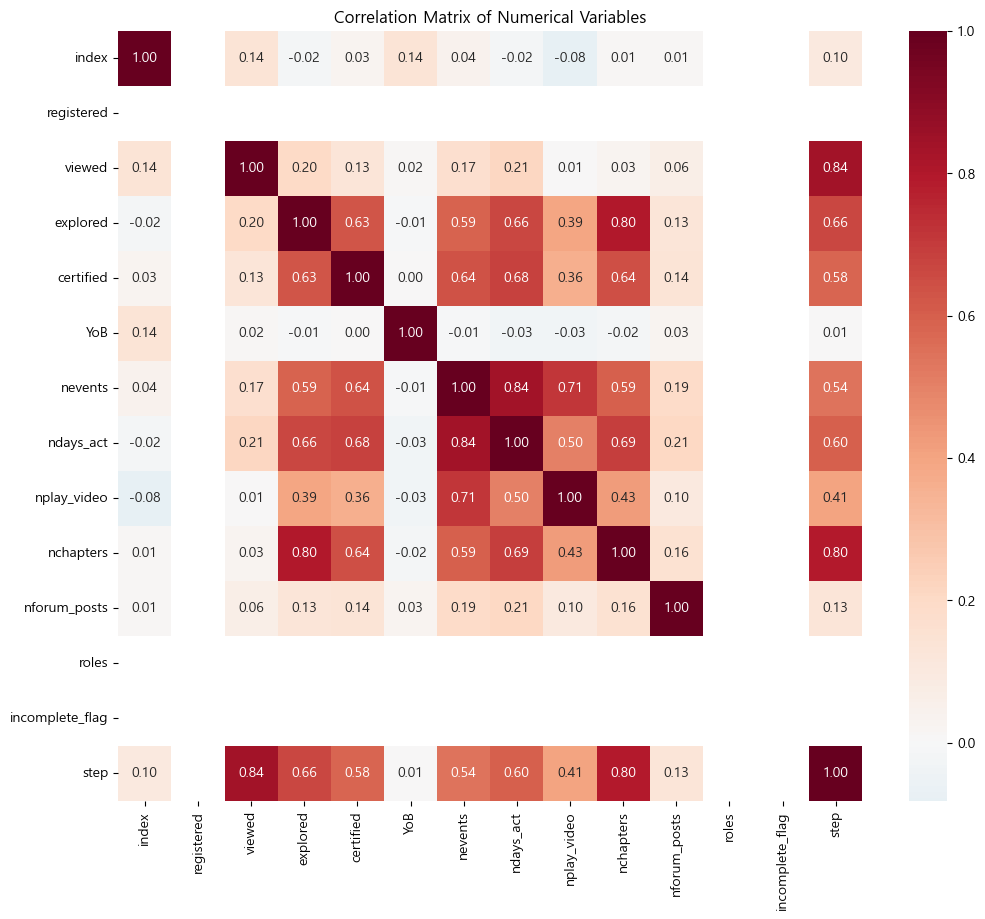

In [5]:
# 수치형 컬럼만 선택
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 상관계수 행렬 계산
corr_matrix = numeric_df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()